# More Practice using nhanes univariate practice
This notebook will give you the opportunity to perform some univariate analyses on your own using the NHANES data.  These analyses are similar to what was done in the week 2 NHANES case study notebook.

You can enter your code into the cells that say "enter your code here", and you can type responses to the questions into the cells that say "Type Markdown and Latex".

Note that most of the code that you will need to write below is very similar to code that appears in the case study notebook.  You will need to edit code from that notebook in small ways to adapt it to the prompts below.

To get started, we will use the same module imports and read the data in the same way as we did in the case study:

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import numpy as np

da = pd.read_csv("C:/Users/ziadt/Desktop/Projects/Coursera - Understanding and Visualizing Data with Python/datasets/nhanes_2015_2016.csv")

## Question 1

Relabel the marital status variable [DMDMARTL](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#DMDMARTL) to have brief but informative character labels.  Then construct a frequency table of these values for all people, then for women only and for men only.  Then construct these three frequency tables using only people whose age is between 30 and 40.

In [3]:
r = {1: "Married", 2: "Widowed", 3: "Divorced", 4: "Separated", 5: "NeverMarried", 6: "Cohabitating", 77: "Refused", 99: "Unknown"} # create a dictionary r with the values to be replaced
da["DMDMARTLx"] = da["DMDMARTL"].replace(r) # replace the values in the DMDMARTL column with the values in the dictionary r

print("All subjects:")
x = da["DMDMARTLx"].value_counts()
print(x / x.sum())

for ky,db in da.groupby("RIAGENDR"):
    print("\nRIAGENDR=", ky)
    x = db["DMDMARTLx"].value_counts()
    print(x / x.sum())
    
# Restrict the sample to people between 30 and 40
da3040 = da.query('RIDAGEYR >= 30 & RIDAGEYR <= 40')
for ky,db in da3040.groupby("RIAGENDR"):
    print("\nRIAGENDR=", ky, " 30 <= RIDAGEYR <= 40")
    x = db["DMDMARTLx"].value_counts()
    print(x / x.sum())


All subjects:
DMDMARTLx
Married         0.507855
NeverMarried    0.183412
Divorced        0.105773
Cohabitating    0.096273
Widowed         0.072342
Separated       0.033979
Refused         0.000365
Name: count, dtype: float64

RIAGENDR= 1
DMDMARTLx
Married         0.562881
NeverMarried    0.184451
Cohabitating    0.100991
Divorced        0.087271
Widowed         0.038110
Separated       0.025915
Refused         0.000381
Name: count, dtype: float64

RIAGENDR= 2
DMDMARTLx
Married         0.457193
NeverMarried    0.182456
Divorced        0.122807
Widowed         0.103860
Cohabitating    0.091930
Separated       0.041404
Refused         0.000351
Name: count, dtype: float64

RIAGENDR= 1  30 <= RIDAGEYR <= 40
DMDMARTLx
Married         0.556680
NeverMarried    0.204453
Cohabitating    0.157895
Divorced        0.048583
Separated       0.024291
Widowed         0.006073
Refused         0.002024
Name: count, dtype: float64

RIAGENDR= 2  30 <= RIDAGEYR <= 40
DMDMARTLx
Married         0.535714
Nev

__Q1a.__ Briefly comment on some of the differences that you observe between the distribution of marital status between women and men, for people of all ages.

Compared to men, women have a lower probability of being currently married, a greater probability of being divorced, and a much greater probability of being widowed compared to men.

__Q1b.__ Briefly comment on the differences that you observe between the distribution of marital status states for women between the overall population, and for women between the ages of 30 and 40.

Women between the ages of 30 and 40 have a much lower probability of being widowed, a lower probability of being divorced, and a greater probability of cohabitating, compared to women of all ages.

__Q1c.__ Repeat part b for the men.

Men between the ages of 30 and 40 have a greater probability of cohabitating, a lower probability of being divorced, and a much lower probability of being widowed, compared to men of all ages.

## Question 2

Restricting to the female population, stratify the subjects into age bands no wider than ten years, and construct the distribution of marital status within each age band.  Within each age band, present the distribution in terms of proportions that must sum to 1.

In [19]:
# Filter the data to only include females (RIAGENDR = 2)
da_females = da[da["RIAGENDR"] == 2]

# Create age strata based on the specified cut points (age bands no wider than 10 years)
da_females["agegrp"] = pd.cut(da_females.RIDAGEYR, [10, 20, 30, 40, 50, 60, 70, 80])

# Check the distribution of subjects within each age group
print(da_females["agegrp"].value_counts())

# Within each age group, present the proportions of marital statuses
for age_group, group_data in da_females.groupby("agegrp"):
    print("\nagegrp =", age_group)
    marital_status_counts = group_data["DMDMARTLx"].value_counts()
    print(marital_status_counts / marital_status_counts.sum())


agegrp
(20, 30]    514
(40, 50]    502
(30, 40]    474
(50, 60]    470
(60, 70]    441
(70, 80]    410
(10, 20]    165
Name: count, dtype: int64

agegrp = (10, 20]
DMDMARTLx
NeverMarried    0.769231
Cohabitating    0.205128
Married         0.025641
Name: count, dtype: float64

agegrp = (20, 30]
DMDMARTLx
NeverMarried    0.445525
Married         0.305447
Cohabitating    0.206226
Separated       0.021401
Divorced        0.021401
Name: count, dtype: float64

agegrp = (30, 40]
DMDMARTLx
Married         0.544304
NeverMarried    0.204641
Cohabitating    0.120253
Divorced        0.090717
Separated       0.035865
Widowed         0.004219
Name: count, dtype: float64

agegrp = (40, 50]
DMDMARTLx
Married         0.573705
Divorced        0.137450
NeverMarried    0.125498
Cohabitating    0.073705
Separated       0.065737
Widowed         0.023904
Name: count, dtype: float64

agegrp = (50, 60]
DMDMARTLx
Married         0.546809
Divorced        0.176596
NeverMarried    0.089362
Cohabitating    0.06808

C:\Users\ziadt\AppData\Local\Temp\ipykernel_31080\249296120.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  da_females["agegrp"] = pd.cut(da_females.RIDAGEYR, [10, 20, 30, 40, 50, 60, 70, 80])
C:\Users\ziadt\AppData\Local\Temp\ipykernel_31080\249296120.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for age_group, group_data in da_females.groupby("agegrp"):


__Q2a.__ Comment on the trends that you see in this series of marginal distributions.

The trends show that:

Younger women (10-20, 20-30): Most are "Never Married," but cohabitation increases with age. Marriage rates rise in the 20-30 group.

Middle age (30-50): Marriage is most common, peaking around 40-50 years. Divorce also becomes more frequent, while cohabitation declines.

Older age (50-80): Marriage decreases, especially for women over 60, as widowhood increases significantly. Divorce rates remain stable, and fewer women are "Never Married."

Overall, marriage is dominant in middle age, while widowhood and divorce become more common as women age.

__Q2b.__ Repeat the analysis for males.

In [18]:
# Filter the data to only include females (RIAGENDR = 2)
da_males = da[da["RIAGENDR"] == 1]

# Create age strata based on the specified cut points (age bands no wider than 10 years)
da_males["agegrp"] = pd.cut(da_males.RIDAGEYR, [10, 20, 30, 40, 50, 60, 70, 80])

# Check the distribution of subjects within each age group
print(da_males["agegrp"].value_counts())

# Within each age group, present the proportions of marital statuses
for age_group, group_data in da_males.groupby("agegrp"):
    print("\nagegrp =", age_group)
    marital_status_counts = group_data["DMDMARTLx"].value_counts()
    print(marital_status_counts / marital_status_counts.sum())


agegrp
(30, 40]    458
(50, 60]    454
(60, 70]    437
(20, 30]    432
(70, 80]    402
(40, 50]    401
(10, 20]    175
Name: count, dtype: int64

agegrp = (10, 20]
DMDMARTLx
NeverMarried    0.900
Cohabitating    0.075
Married         0.025
Name: count, dtype: float64

agegrp = (20, 30]
DMDMARTLx
NeverMarried    0.523148
Married         0.238426
Cohabitating    0.212963
Separated       0.016204
Divorced        0.004630
Widowed         0.004630
Name: count, dtype: float64

agegrp = (30, 40]
DMDMARTLx
Married         0.563319
NeverMarried    0.194323
Cohabitating    0.157205
Divorced        0.052402
Separated       0.026201
Widowed         0.004367
Refused         0.002183
Name: count, dtype: float64

agegrp = (40, 50]
DMDMARTLx
Married         0.703242
NeverMarried    0.097257
Divorced        0.084788
Cohabitating    0.082294
Separated       0.027431
Widowed         0.004988
Name: count, dtype: float64

agegrp = (50, 60]
DMDMARTLx
Married         0.651982
Divorced        0.125551
NeverMa

C:\Users\ziadt\AppData\Local\Temp\ipykernel_31080\1971314039.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  da_males["agegrp"] = pd.cut(da_males.RIDAGEYR, [10, 20, 30, 40, 50, 60, 70, 80])
C:\Users\ziadt\AppData\Local\Temp\ipykernel_31080\1971314039.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for age_group, group_data in da_males.groupby("agegrp"):


__Q2c.__ Comment on any notable differences that you see when comparing these results between females and for males.

Males tend to remain married longer, while females are more likely to experience widowhood in later life. Additionally, more males remain "Never Married" compared to females. These differences reflect broader gender trends in marriage, divorce, and life expectancy.

In [22]:
# Females data
da_females = da[da["RIAGENDR"] == 2]
da_females["agegrp"] = pd.cut(da_females.RIDAGEYR, [10, 20, 30, 40, 50, 60, 70, 80])

# Males data
da_males = da[da["RIAGENDR"] == 1]
da_males["agegrp"] = pd.cut(da_males.RIDAGEYR, [10, 20, 30, 40, 50, 60, 70, 80])

# Grouping and comparing the distribution of marital statuses by age group and gender
female_marital_dist = da_females.groupby("agegrp")["DMDMARTLx"].value_counts(normalize=True).unstack()
male_marital_dist = da_males.groupby("agegrp")["DMDMARTLx"].value_counts(normalize=True).unstack()

# Displaying the comparison side by side
comparison_df = pd.concat([female_marital_dist, male_marital_dist], keys=['Females', 'Males'], axis=1)
print(comparison_df)


               Females                                                       \
DMDMARTLx Cohabitating  Divorced   Married NeverMarried   Refused Separated   
agegrp                                                                        
(10, 20]      0.205128  0.000000  0.025641     0.769231  0.000000  0.000000   
(20, 30]      0.206226  0.021401  0.305447     0.445525  0.000000  0.021401   
(30, 40]      0.120253  0.090717  0.544304     0.204641  0.000000  0.035865   
(40, 50]      0.073705  0.137450  0.573705     0.125498  0.000000  0.065737   
(50, 60]      0.068085  0.176596  0.546809     0.089362  0.002128  0.057447   
(60, 70]      0.043084  0.192744  0.480726     0.086168  0.000000  0.049887   
(70, 80]      0.007317  0.143902  0.317073     0.051220  0.000000  0.019512   

                           Males                                             \
DMDMARTLx   Widowed Cohabitating  Divorced   Married NeverMarried   Refused   
agegrp                                             

C:\Users\ziadt\AppData\Local\Temp\ipykernel_31080\2933770577.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  da_females["agegrp"] = pd.cut(da_females.RIDAGEYR, [10, 20, 30, 40, 50, 60, 70, 80])
C:\Users\ziadt\AppData\Local\Temp\ipykernel_31080\2933770577.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  da_males["agegrp"] = pd.cut(da_males.RIDAGEYR, [10, 20, 30, 40, 50, 60, 70, 80])
C:\Users\ziadt\AppData\Local\Temp\ipykernel_31080\2933770577.py:10: FutureWarning: The default of observed=False is depr

__Q2c.__ Comment on any notable differences that you see when comparing these results between females and for males.

Males tend to remain married longer, while females are more likely to experience widowhood in later life. Additionally, more males remain "Never Married" compared to females. These differences reflect broader gender trends in marriage, divorce, and life expectancy.

## Question 3

Construct a histogram of the distribution of heights using the BMXHT variable in the NHANES sample.

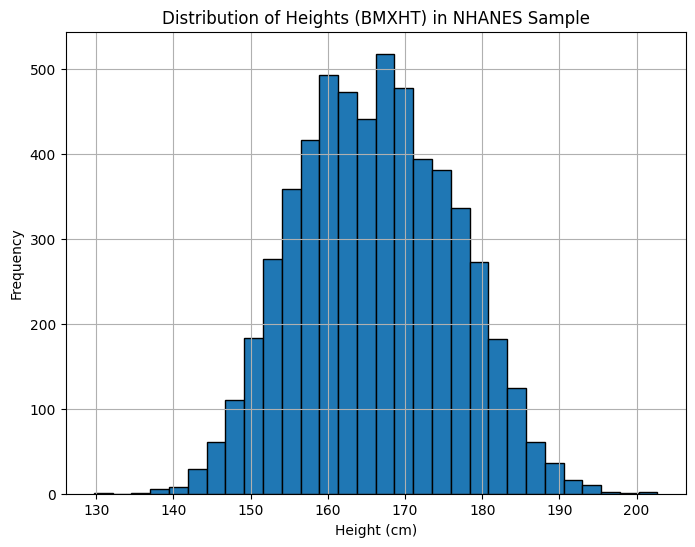

In [25]:
import matplotlib.pyplot as plt

# Assuming 'da' is the NHANES dataset already loaded
# Creating a histogram of the distribution of heights (BMXHT variable)

plt.figure(figsize=(8, 6))
plt.hist(da['BMXHT'].dropna(), bins=30, edgecolor='black')
plt.title('Distribution of Heights (BMXHT) in NHANES Sample')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


__Q3a.__ Use the `bins` argument to [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn.histplot) to produce histograms with different numbers of bins.  Assess whether the default value for this argument gives a meaningful result, and comment on what happens as the number of bins grows excessively large or excessively small. 

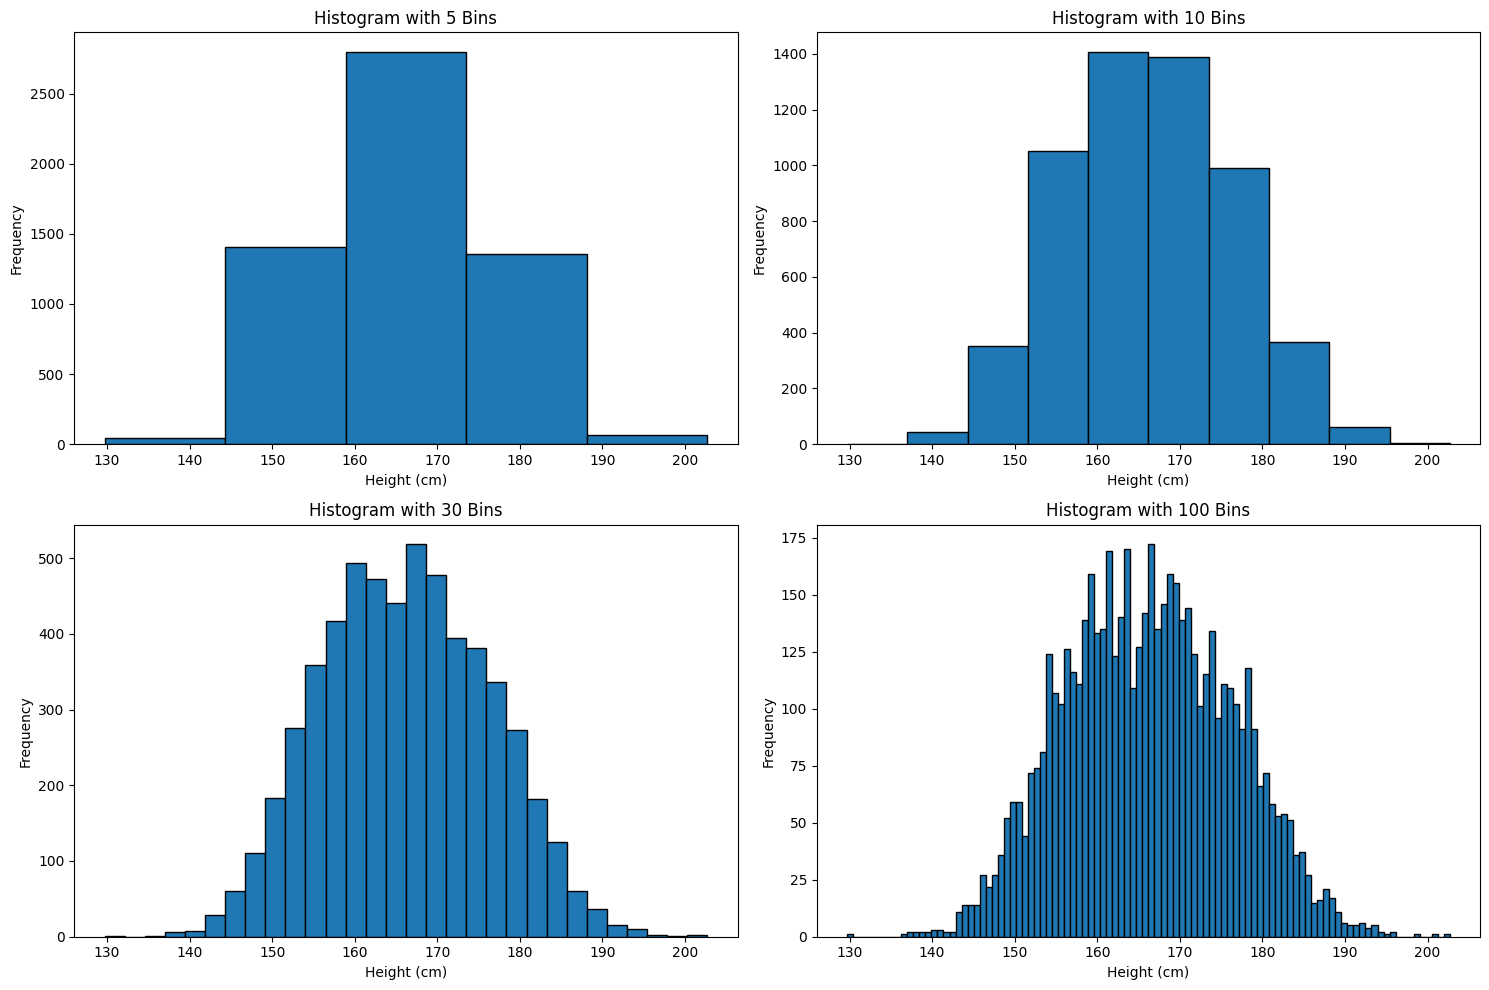

In [26]:
import matplotlib.pyplot as plt

# Define the different bin sizes to test
bin_sizes = [5, 10, 30, 100]

# Plot histograms with different bin sizes
plt.figure(figsize=(15, 10))

for i, bins in enumerate(bin_sizes, start=1):
    plt.subplot(2, 2, i)  # Create a 2x2 grid of subplots
    plt.hist(da['BMXHT'].dropna(), bins=bins, edgecolor='black')
    plt.title(f'Histogram with {bins} Bins')
    plt.xlabel('Height (cm)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


The default bin size (around 30) generally provides a meaningful representation of the data. Using too few bins oversimplifies the data, while too many bins introduce noise and obscure the overall trends. The ideal number of bins depends on the size and distribution of the data but typically lies between 20-50 for most datasets.

__Q3b.__ Make separate histograms for the heights of women and men, then make a side-by-side boxplot showing the heights of women and men.

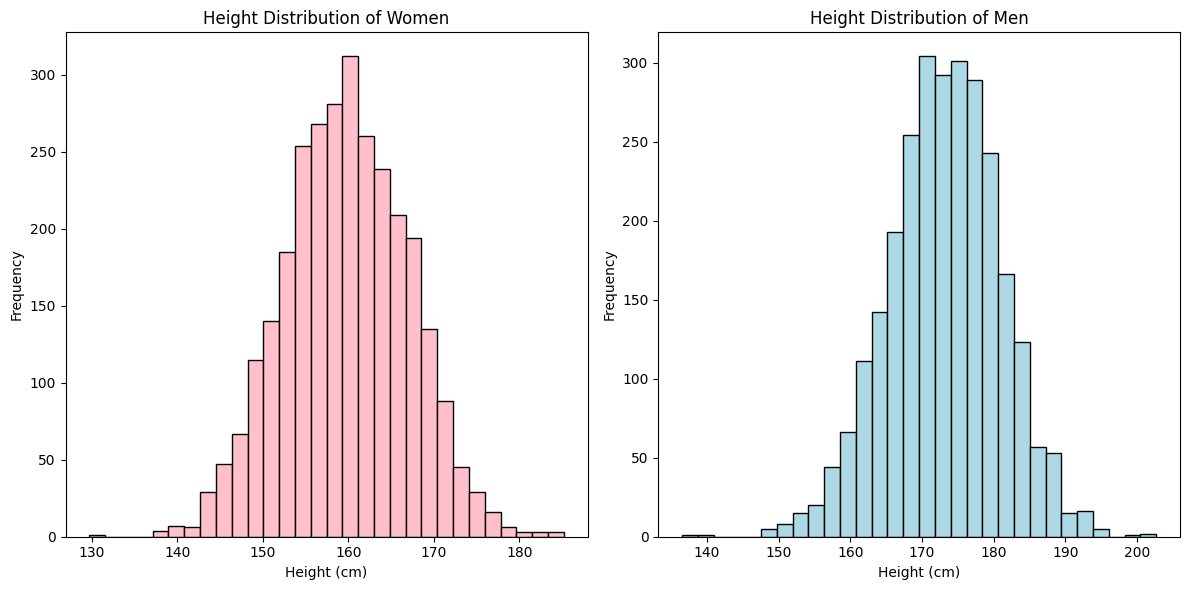

C:\Users\ziadt\AppData\Local\Temp\ipykernel_31080\871324865.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([female_heights, male_heights], labels=['Women', 'Men'])


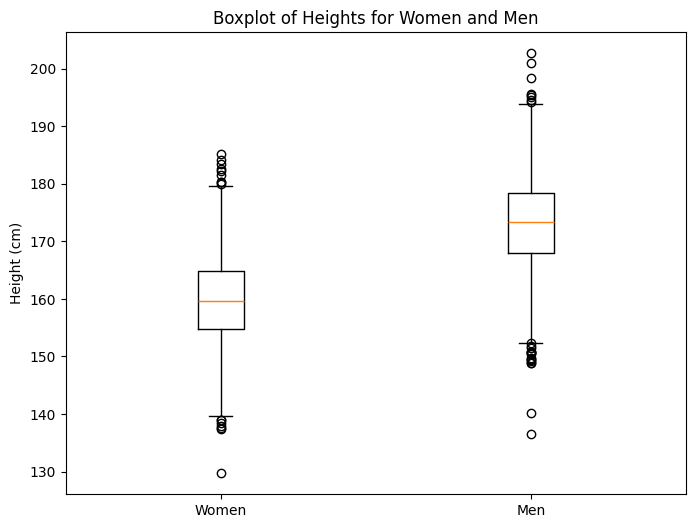

In [27]:
# Filter data for males and females
female_heights = da[da['RIAGENDR'] == 2]['BMXHT'].dropna()
male_heights = da[da['RIAGENDR'] == 1]['BMXHT'].dropna()

# Create histograms for males and females
plt.figure(figsize=(12, 6))

# Histogram for females
plt.subplot(1, 2, 1)
plt.hist(female_heights, bins=30, edgecolor='black', color='pink')
plt.title('Height Distribution of Women')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')

# Histogram for males
plt.subplot(1, 2, 2)
plt.hist(male_heights, bins=30, edgecolor='black', color='lightblue')
plt.title('Height Distribution of Men')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Create a side-by-side boxplot for male and female heights
plt.figure(figsize=(8, 6))
plt.boxplot([female_heights, male_heights], labels=['Women', 'Men'])
plt.title('Boxplot of Heights for Women and Men')
plt.ylabel('Height (cm)')
plt.show()


Features Not Represented Clearly in Boxplots:
1. Distribution Shape: Boxplots do not show the actual distribution shape (e.g., whether the data is unimodal, bimodal, or skewed). Histograms reveal how the data is spread across various height ranges, which helps in identifying peaks or the skewness of the distribution.

2. Frequency of Data: Histograms provide insight into the frequency of specific height ranges, showing how many individuals fall within each bin. This is missing in boxplots, which only show summary statistics (median, quartiles, etc.).

Features Easier to See in Boxplots:
1. Summary Statistics: Boxplots clearly present key summary statistics like the median, interquartile range (IQR), and potential outliers. It’s easier to identify the central tendency (median) and the spread of the data in a boxplot.

2. Outliers: Outliers are highlighted in boxplots, making them easier to spot. In histograms, outliers might appear as small bars at the extreme ends, but boxplots visually emphasize them as separate points.

Summary:
Histograms are better for understanding the shape of the distribution and the frequency of specific values.
Boxplots are more effective for quickly summarizing the data and identifying central tendencies, variability, and outliers.


## Question 4

Make a boxplot showing the distribution of within-subject differences between the first and second systolic blood pressure measurents ([BPXSY1](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BPX_I.htm#BPXSY1) and [BPXSY2](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BPX_I.htm#BPXSY2)).

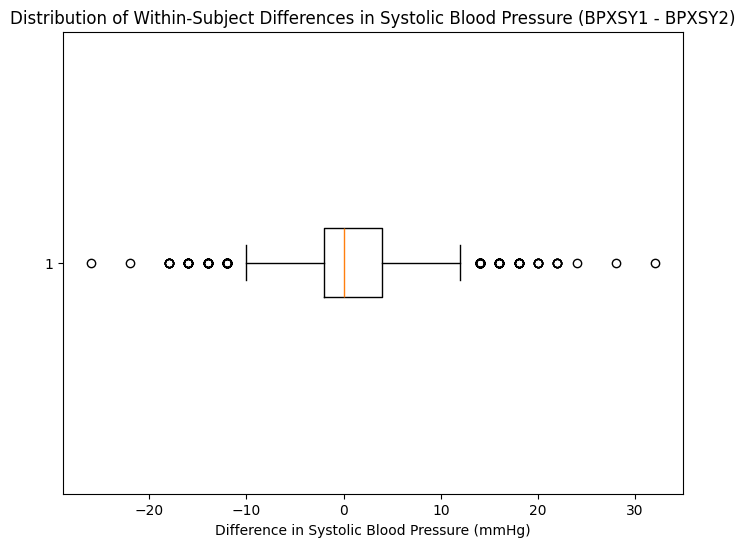

In [31]:
# Assuming 'da' is the NHANES dataset and it contains BPXSY1 and BPXSY2 variables

# Calculate within-subject differences between the first and second systolic blood pressure measurements
da['BP_diff'] = da['BPXSY1'] - da['BPXSY2']

# Create a boxplot to show the distribution of these differences
plt.figure(figsize=(8, 6))
plt.boxplot(da['BP_diff'].dropna(), vert=False)
plt.title('Distribution of Within-Subject Differences in Systolic Blood Pressure (BPXSY1 - BPXSY2)')
plt.xlabel('Difference in Systolic Blood Pressure (mmHg)')
plt.show()



__Q4a.__ What proportion of the subjects have a lower SBP on the second reading compared to the first?

In [32]:
# Calculate the proportion of subjects where the second systolic blood pressure reading (BPXSY2) is lower than the first (BPXSY1)
lower_sbp_count = (da['BPXSY2'] < da['BPXSY1']).sum()
total_subjects = da['BPXSY1'].notna().sum()  # Count of non-missing values in BPXSY1
proportion_lower_sbp = lower_sbp_count / total_subjects

print(f"Proportion of subjects with lower SBP on second reading: {proportion_lower_sbp:.4f}")


Proportion of subjects with lower SBP on second reading: 0.4560


__Q4b.__ Make side-by-side boxplots of the two systolic blood pressure variables.

C:\Users\ziadt\AppData\Local\Temp\ipykernel_31080\1573574976.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([da['BPXSY1'].dropna(), da['BPXSY2'].dropna()], labels=['BPXSY1', 'BPXSY2'])


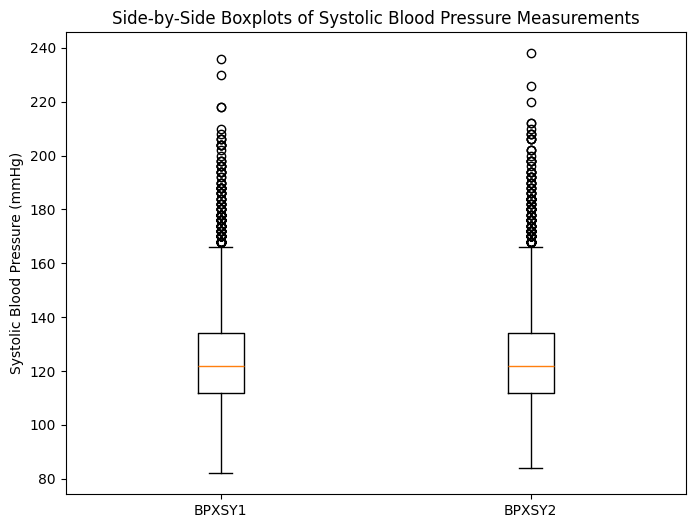

In [33]:
# Create side-by-side boxplots of the two systolic blood pressure variables
plt.figure(figsize=(8, 6))
plt.boxplot([da['BPXSY1'].dropna(), da['BPXSY2'].dropna()], labels=['BPXSY1', 'BPXSY2'])
plt.title('Side-by-Side Boxplots of Systolic Blood Pressure Measurements')
plt.ylabel('Systolic Blood Pressure (mmHg)')
plt.show()


__Q4c.__ Comment on the variation within either the first or second systolic blood pressure measurements, and the variation in the within-subject differences between the first and second systolic blood pressure measurements.


Both systolic blood pressure measurements (BPXSY1 and BPXSY2) show similar distributions, with close medians and interquartile ranges. Both have many high outliers above 160 mmHg. The within-subject differences would reveal if the readings vary significantly, but based on the boxplots, the overall variation between the two measurements is minimal.